# Customer Segmentation Models

## Step 1 : Data Collection

In [1]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect(r'D:\Imarticus Learning- PGA 45\GitHub Projects\h & m db\hm_database.db')
query = '''
SELECT 
    c.customer_id,
    c.age,
    c.club_member_status,
    MAX(t.t_dat) as last_purchase_date,
    COUNT(t.article_id) as frequency,
    SUM(t.price) as monetary
FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
GROUP BY c.customer_id
LIMIT 1000000;
'''
df = pd.read_sql_query(query, conn)
conn.close()

In [3]:
df.head()

,customer_id,age,club_member_status,last_purchase_date,frequency,monetary
0,0,49.0,ACTIVE,2020-09-05,13,0.393186
1,1,25.0,ACTIVE,2020-07-08,35,0.887542
2,2,24.0,ACTIVE,2020-09-15,14,0.559085
3,4,52.0,ACTIVE,2020-08-12,9,0.359593
4,5,NaN,None,2019-10-02,3,0.101644


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   customer_id         1000000 non-null  int64  
 1   age                 991940 non-null   float64
 2   club_member_status  997236 non-null   object 
 3   last_purchase_date  1000000 non-null  object 
 4   frequency           1000000 non-null  int64  
 5   monetary            1000000 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 45.8+ MB


In [5]:
df.describe()

,customer_id,age,frequency,monetary
count,1.000000e+06,991940.000000,1000000.000000,1000000.000000
mean,6.806749e+05,35.750501,15.333059,0.435216
std,3.930595e+05,14.267030,22.617114,0.702995
min,0.000000e+00,16.000000,1.000000,0.000763
25%,3.401298e+05,24.000000,3.000000,0.084678
50%,6.804805e+05,31.000000,8.000000,0.204949
75%,1.021108e+06,48.000000,18.000000,0.498597
max,1.361587e+06,99.000000,1046.000000,34.954610


## Step 2 : Data Cleaning & Preprocessing

### Check Missing Values

In [6]:
df.isnull().sum()

customer_id              0
age                   8060
club_member_status    2764
last_purchase_date       0
frequency                0
monetary                 0
dtype: int64

### Handle Missing Values

In [7]:
df['age'] = df['age'].fillna(df['age'].median())
df['club_member_status'] = df['club_member_status'].fillna('NONE')

In [8]:
df.isnull().sum() # Verify missing values are handled

customer_id           0
age                   0
club_member_status    0
last_purchase_date    0
frequency             0
monetary              0
dtype: int64

### Feature Engineering (Recency)

In [9]:
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])
reference_date = df['last_purchase_date'].max()
df['recency'] = (reference_date - df['last_purchase_date']).dt.days

### Encode Categorical Variables

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['club_member_status'] = le.fit_transform(df['club_member_status'])

### Scale Features

In [11]:
from sklearn.preprocessing import StandardScaler
features = ['age', 'recency', 'frequency', 'monetary', 'club_member_status']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 3 : EDA

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

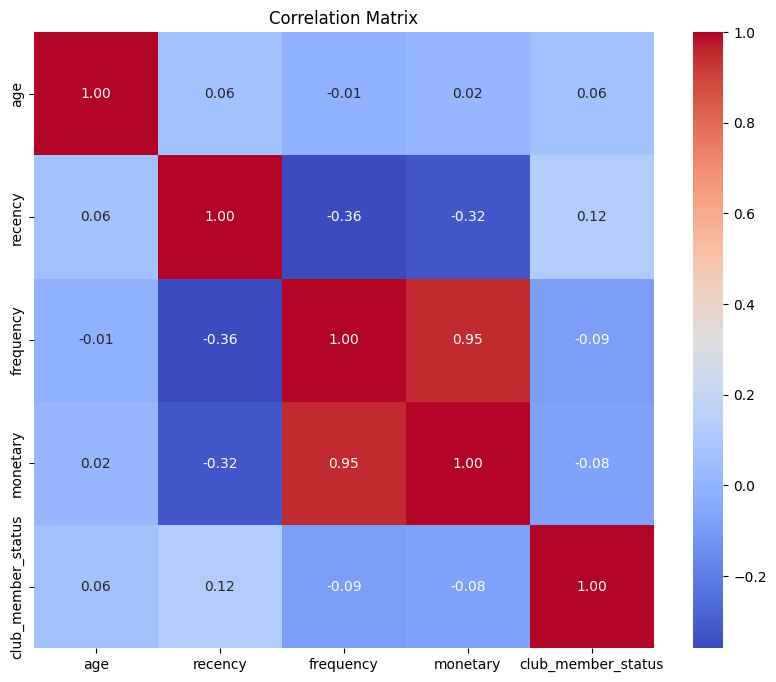

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Distribution of Recency ,Frequency and Monetary Value

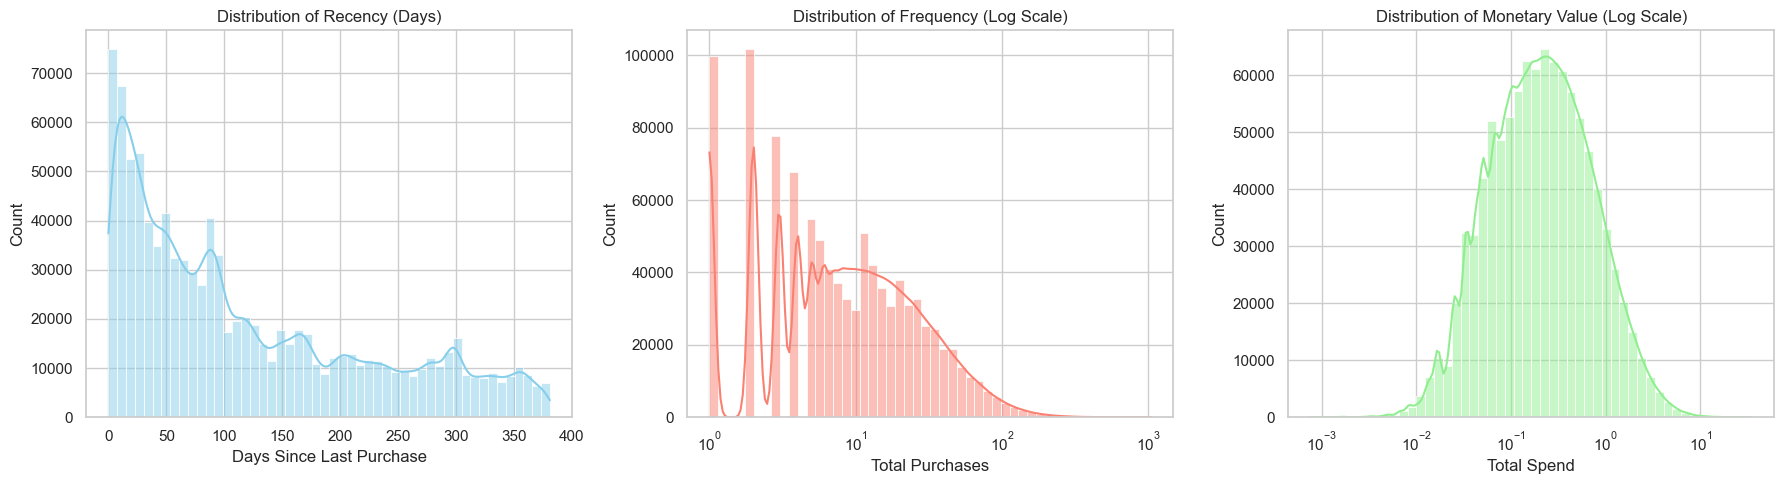

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for all plots
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
sns.histplot(df['recency'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Recency (Days)')
axes[0].set_xlabel('Days Since Last Purchase')

# Frequency (Log scale due to extreme VIPs)
sns.histplot(df['frequency'], bins=50, kde=True, log_scale=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Frequency (Log Scale)')
axes[1].set_xlabel('Total Purchases')

# Monetary (Log scale due to extreme VIPs)
sns.histplot(df['monetary'], bins=50, kde=True, log_scale=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Monetary Value (Log Scale)')
axes[2].set_xlabel('Total Spend')

plt.tight_layout()
plt.show()

### Boxplots (Outlier Detection)

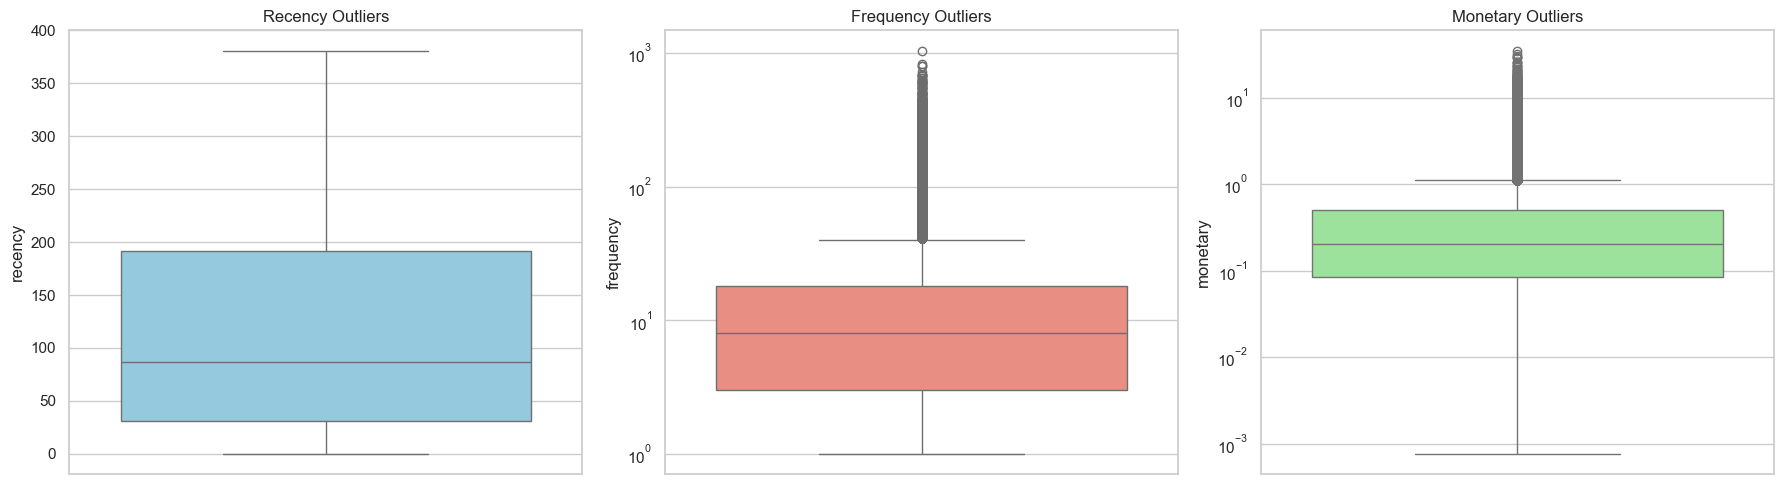

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['recency'], ax=axes[0], color='skyblue')
axes[0].set_title('Recency Outliers')

sns.boxplot(y=df['frequency'], ax=axes[1], color='salmon')
axes[1].set_title('Frequency Outliers')
axes[1].set_yscale('log') # Log scale because of extreme outliers

sns.boxplot(y=df['monetary'], ax=axes[2], color='lightgreen')
axes[2].set_title('Monetary Outliers')
axes[2].set_yscale('log') # Log scale because of extreme outliers

plt.tight_layout()
plt.show()


### Age vs. Club Member Status

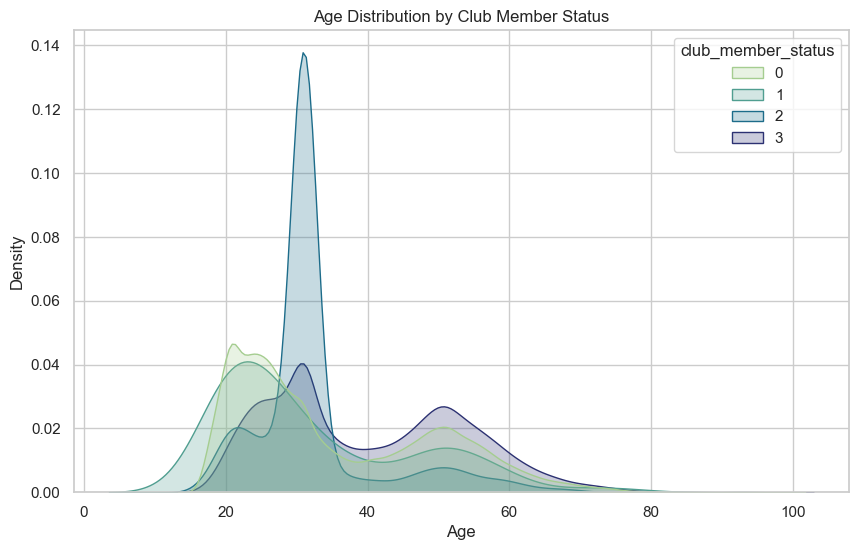

In [16]:
plt.figure(figsize=(10, 6))

# We use the kdeplot to see the age waves for different member statuses
sns.kdeplot(data=df, x='age', hue='club_member_status', fill=True, common_norm=False, palette='crest')

plt.title('Age Distribution by Club Member Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()


### The 3D Scatter (Recency vs Frequency vs Monetary)

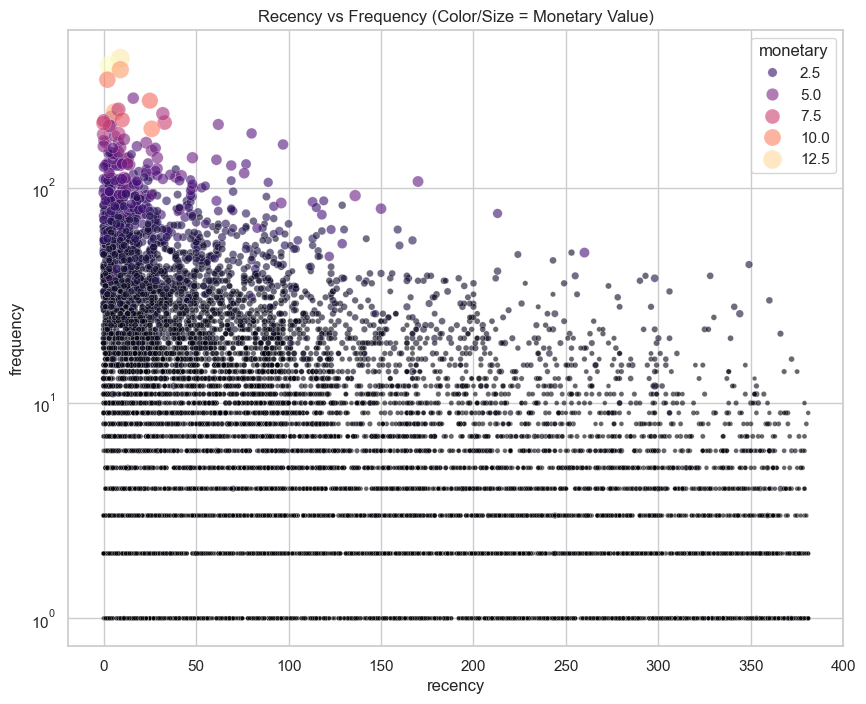

In [17]:
plt.figure(figsize=(10, 8))

# We sample 10,000 users so the computer doesn't crash drawing 1.3 million dots!
sns.scatterplot(
    data=df.sample(10000, random_state=42), 
    x='recency', 
    y='frequency', 
    size='monetary', 
    hue='monetary', 
    palette='magma', 
    sizes=(10, 200), 
    alpha=0.6
)

plt.title('Recency vs Frequency (Color/Size = Monetary Value)')
plt.yscale('log') # Log scale for frequency
plt.show()


## Step 4 : Data Spliting

For unsupervised clustering, we don't strictly split into train/test, but we will reduce dimensions using PCA for visualization.

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## Step 5 : Model Building

### 5.1 Basic Baseline: K-Means

In [19]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [27]:
# We slice the first 20,000 rows from the massive X_scaled matrix
kmeans_sample_X = X_scaled[:20000]

# We slice the first 20,000 labels from the massive dataframe column
kmeans_sample_labels = df['kmeans_cluster'][:20000]

### 5.2 Intermediate: Agglomerative Clustering

In [21]:
from sklearn.cluster import AgglomerativeClustering

print("Sampling data to prevent 3.6 Terabyte Memory Crash...")

# 1. Create a small 20,000 row sample of both the raw dataframe and the scaled data
df_sample = df.sample(n=20000, random_state=42).copy()
X_scaled_sample = X_scaled[:20000] 

# 2. Run the clustering on the small sample
agg = AgglomerativeClustering(n_clusters=4)
df_sample['agg_cluster'] = agg.fit_predict(X_scaled_sample)

print("Agglomerative Clustering finished successfully on the sample!")

Sampling data to prevent 3.6 Terabyte Memory Crash...
Agglomerative Clustering finished successfully on the sample!


### 5.3 Advanced: Gaussian Mixture Models

In [22]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=42)
df['gmm_cluster'] = gmm.fit_predict(X_scaled)

In [31]:
gmm_sample_X = X_scaled[:20000]
gmm_sample_labels = df['gmm_cluster'][:20000]

### 5.4 Advanced: DBSCAN

In [24]:
from sklearn.cluster import DBSCAN

print("Running DBSCAN on the 20k sample to prevent Memory Crash...")

# We use the exact same X_scaled_sample and df_sample we created in the Agglomerative step!
dbscan = DBSCAN(eps=0.8, min_samples=10)

# Notice we are using the "sample" variables here, not the massive 1.3M row variables!
df_sample['dbscan_cluster'] = dbscan.fit_predict(X_scaled_sample)

print("DBSCAN finished successfully on the sample!")

Running DBSCAN on the 20k sample to prevent Memory Crash...
DBSCAN finished successfully on the sample!


## Step 6 : Model Evaluation

In [25]:
from sklearn.metrics import silhouette_score

In [28]:
print('K-Means Silhouette:', silhouette_score(kmeans_sample_X, kmeans_sample_labels))

K-Means Silhouette: 0.3663260223016352


In [29]:
print('Agglomerative Silhouette:', silhouette_score(X_scaled_sample, df_sample['agg_cluster']))

Agglomerative Silhouette: 0.3154345329309782


In [32]:
print('GMM Silhouette:', silhouette_score(gmm_sample_X, gmm_sample_labels))

GMM Silhouette: 0.28032178390655765


In [34]:
import numpy as np
# We use the df_sample and X_scaled_sample from Step 5.4
dbscan_labels = df_sample['dbscan_cluster'].values
# Create a "mask" to filter out all the noise points (-1)
mask = dbscan_labels != -1
# Apply the mask so we only calculate the score on actual clustered points
if np.sum(mask) > 0 and len(set(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(X_scaled_sample[mask], dbscan_labels[mask])
    print('DBSCAN Silhouette (excluding noise):', dbscan_score)
else:
    print('DBSCAN Silhouette: Not enough clusters formed (only noise).')

DBSCAN Silhouette (excluding noise): 0.4021801386210003


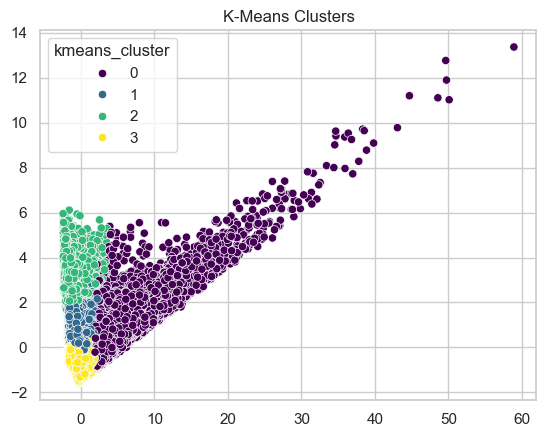

In [35]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['kmeans_cluster'], palette='viridis')
plt.title('K-Means Clusters')
plt.show()

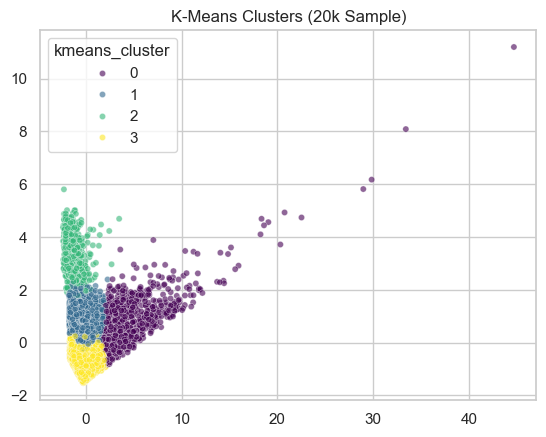

In [36]:
# We slice only the first 20,000 rows from X_pca and the first 20,000 labels from K-Means
sns.scatterplot(
    x=X_pca[:20000, 0], 
    y=X_pca[:20000, 1], 
    hue=df['kmeans_cluster'][:20000], 
    palette='viridis',
    alpha=0.6, # This makes the dots slightly transparent so we can see overlapping clusters
    s=20 # This makes the dots smaller
)

plt.title('K-Means Clusters (20k Sample)')
plt.show()

## Step 7 : Model Tuning

### Basic Tuning: Elbow Method

In [37]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

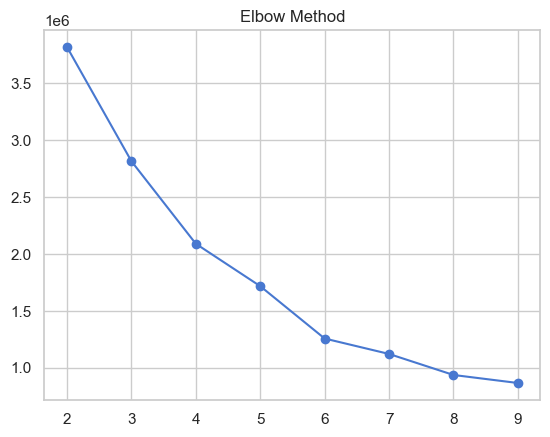

In [38]:
plt.plot(range(2, 10), inertias, marker='o')
plt.title('Elbow Method')
plt.show()

Calculating the Elbow Curve...


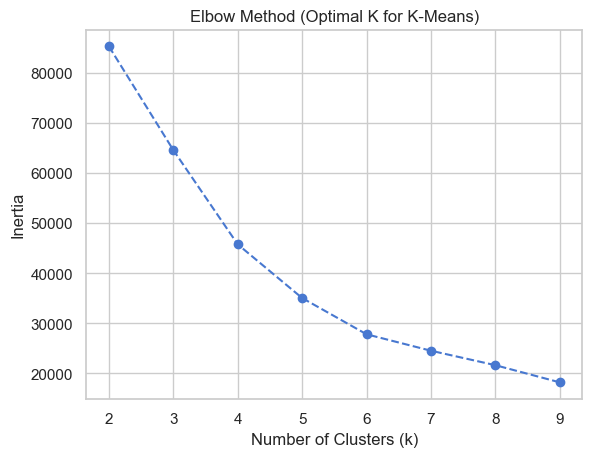

In [39]:
inertias = []
# We use our 20k sample to find the elbow in 5 seconds instead of 5 hours!
kmeans_sample_X = X_scaled[:20000]

print("Calculating the Elbow Curve...")
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(kmeans_sample_X) # Fit only on the sample!
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker='o', linestyle='--')
plt.title('Elbow Method (Optimal K for K-Means)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

### Advanced Tuning: GMM Grid Search

In [41]:
import numpy as np
from sklearn.mixture import GaussianMixture

best_bic = np.inf
best_gmm = None

print("Tuning GMM Parameters on sample...")
for cv_type in ['spherical', 'tied', 'diag', 'full']:
    for n_comp in range(2, 7):
        gmm_tune = GaussianMixture(n_components=n_comp, covariance_type=cv_type, random_state=42)
        
        # Fit and calculate BIC strictly on the sample
        gmm_tune.fit(kmeans_sample_X)
        bic = gmm_tune.bic(kmeans_sample_X)
        
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm_tune

print('Best GMM Params:', best_gmm.get_params())

Tuning GMM Parameters on sample...
Best GMM Params: {'covariance_type': 'full', 'init_params': 'kmeans', 'max_iter': 100, 'means_init': None, 'n_components': 6, 'n_init': 1, 'precisions_init': None, 'random_state': 42, 'reg_covar': 1e-06, 'tol': 0.001, 'verbose': 0, 'verbose_interval': 10, 'warm_start': False, 'weights_init': None}


In [42]:
# We group all 1.3 million customers by their K-Means cluster and find their average stats!
cluster_profile = df.groupby('kmeans_cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'age': 'mean',
    'customer_id': 'count' # This tells us how many people are in each group
}).round(2)

# Rename the count column so it makes sense
cluster_profile.rename(columns={'customer_id': 'Total_Customers'}, inplace=True)

print("--- CLUSTER PROFILES ---")
print(cluster_profile)


--- CLUSTER PROFILES ---
                recency  frequency  monetary    age  Total_Customers
kmeans_cluster                                                      
0                 29.92      75.34      2.28  35.72            73849
1                134.61      10.24      0.29  52.47           323110
2                182.95       5.56      0.17  39.68            43565
3                118.29      11.12      0.29  25.72           559476


In [43]:
# 1. Create a dictionary mapping the cluster numbers to our new Persona Names
persona_map = {
    0: "The VIP Champions",
    1: "Older Occasional Shoppers",
    2: "The Ghosts (Lost)",
    3: "Young Trend-Chasers"
}

# 2. Create a new column in the original dataframe with the human-readable names
df['Persona'] = df['kmeans_cluster'].map(persona_map)

# 3. Recalculate the profile using the new 'Persona' column instead of numbers
cluster_profile_named = df.groupby('Persona').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'age': 'mean',
    'customer_id': 'count'
}).round(2)

# Rename the count column
cluster_profile_named.rename(columns={'customer_id': 'Total_Customers'}, inplace=True)

print("--- FINAL MARKETING PERSONAS ---")
print(cluster_profile_named)

--- FINAL MARKETING PERSONAS ---
                           recency  frequency  monetary    age  \
Persona                                                          
Older Occasional Shoppers   134.61      10.24      0.29  52.47   
The Ghosts (Lost)           182.95       5.56      0.17  39.68   
The VIP Champions            29.92      75.34      2.28  35.72   
Young Trend-Chasers         118.29      11.12      0.29  25.72   

                           Total_Customers  
Persona                                     
Older Occasional Shoppers           323110  
The Ghosts (Lost)                    43565  
The VIP Champions                    73849  
Young Trend-Chasers                 559476  


## Step 8 : Model Deployment

In [44]:
import joblib
joblib.dump(best_gmm, 'segmentation_gmm.pkl')
joblib.dump(scaler, 'segmentation_scaler.pkl')

['segmentation_scaler.pkl']